In [105]:
import torch
device = torch.device(
"cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

Device: cuda


In [106]:
sentences = [
"king is a royal man",
"queen is a royal woman",
"king rules the kingdom",
"queen rules the kingdom",
"king lives in the palace",
"queen lives in the palace",
"prince is a young man",
"princess is a young woman",
"prince lives in the palace",
"princess lives in the palace",
"man is a male person",
"woman is a female person",
"boy is a young male",
"girl is a young female",
"dog is an animal",
"cat is an animal",
"dog is a pet",
"cat is a pet",
"puppy is a young dog",
"kitten is a young cat",
"apple is a fruit",
"banana is a fruit",
"orange is a fruit",
"apple is sweet",
"banana is sweet",
"orange is sweet",
"car is a vehicle",
"bus is a vehicle",
"truck is a vehicle",
"car moves on road",
"bus moves on road",
"truck moves on road",
]


# Tokenize - 토큰화
corpus = []

for sentence in sentences:
    tokens = sentence.lower().split()
    corpus.append(tokens)

for tokens in corpus[:5]:
    print(tokens)

['king', 'is', 'a', 'royal', 'man']
['queen', 'is', 'a', 'royal', 'woman']
['king', 'rules', 'the', 'kingdom']
['queen', 'rules', 'the', 'kingdom']
['king', 'lives', 'in', 'the', 'palace']


In [107]:

# Build vocabulary - 단어장 40개 생성 -> 40개의 고유 단어를 모아서 각각 ID 부여
words = []
for sentence in corpus:
   words.extend(sentence)

# 단어장 생성
vocab = sorted(set(words))

# 단어에 ID 부여
word_to_id = {
    word: i
    for i, word in enumerate(vocab)
}

id_to_word = {
    i: word
    for word, i in word_to_id.items()
}
vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)
print(word_to_id)

Vocabulary size: 40
{'a': 0, 'an': 1, 'animal': 2, 'apple': 3, 'banana': 4, 'boy': 5, 'bus': 6, 'car': 7, 'cat': 8, 'dog': 9, 'female': 10, 'fruit': 11, 'girl': 12, 'in': 13, 'is': 14, 'king': 15, 'kingdom': 16, 'kitten': 17, 'lives': 18, 'male': 19, 'man': 20, 'moves': 21, 'on': 22, 'orange': 23, 'palace': 24, 'person': 25, 'pet': 26, 'prince': 27, 'princess': 28, 'puppy': 29, 'queen': 30, 'road': 31, 'royal': 32, 'rules': 33, 'sweet': 34, 'the': 35, 'truck': 36, 'vehicle': 37, 'woman': 38, 'young': 39}


In [108]:
# Generate Skip-gram Training Pair 
# corpus 순회하면서 중심, 주변 학습 데이터 쌍 생성 / window 크기 2로 설정
def generate_skipgram_pairs(corpus, window=2):
    pairs = []

    for sentence in corpus:

        for i in range(len(sentence)):
            center_word = sentence[i] # 중심 단어
            start = max(0, i - window)
            end = min(len(sentence),i + window + 1)

            for j in range(start, end):
                if i == j:
                    continue
        
                context_word = sentence[j]

                center_id = word_to_id[center_word]
                context_id = word_to_id[context_word]
                pairs.append((center_id, context_id))
    return pairs

# pair 생성
pairs = generate_skipgram_pairs(corpus,window=2)

print("Number of training pairs:", len(pairs))

# 페어 출력해서 보기!
for center_id, context_id in pairs[:20]:
    print(id_to_word[center_id], "->", id_to_word[context_id])

Number of training pairs: 364
king -> is
king -> a
is -> king
is -> a
is -> royal
a -> king
a -> is
a -> royal
a -> man
royal -> is
royal -> a
royal -> man
man -> a
man -> royal
queen -> is
queen -> a
is -> queen
is -> a
is -> royal
a -> queen


In [109]:
 # 훈련 데이터를 텐서로 바꾸기
# 중심 단어만!
center_words = torch.tensor( [pair[0] for pair in pairs ], dtype = torch.long )
# 주변 단어만!
context_words = torch.tensor( [pair[1] for pair in pairs], dtype=torch.long )

# 중심 단어(center word)를 보고 주변 단어(context word)를 예측하기 위해서!!
print(center_words.shape)
print(context_words.shape)


torch.Size([364])
torch.Size([364])


In [110]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# 중심, 주변으로 묶기
dataset = TensorDataset(center_words,context_words)

# 64개의 배치 사이즈로 제공
loader = DataLoader(dataset,batch_size=64,shuffle=True)

In [111]:
# Skip-gram 신경망 생성
import torch.nn as nn

class SkipGramModel(nn.Module):
    def __init__( self, vocab_size, embedding_dim ):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_words):

        # 중심 단어 ID를 embedding vector로 바꾸기
        embedded = self.embedding(center_words)
        # 밑LLM에서 배운 것 처럼 특정 단어를 통과 시키면 해당 단어에 대한 embedding_dim차원 백터가 나옴!

        # embedding(백터를) -> vocabulary logits(40개의 점수 결과가 나온당)
        logits = self.output(embedded)

        return logits

In [112]:
# SkipGramModel 생성하고 구조 확인하기
embedding_dim = 50
model = SkipGramModel(vocab_size,embedding_dim)
model = model.to(device)
print(model)

SkipGramModel(
  (embedding): Embedding(40, 50)
  (output): Linear(in_features=50, out_features=40, bias=True)
)


In [113]:
# Loss & optimizer

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [114]:
# Word2Vec 훈련

# 200번 
epochs = 200 

for epoch in range(epochs):
    total_loss = 0

    for centers, contexts in loader:
        centers = centers.to(device)
        contexts = contexts.to(device)

        # 그레디언트 초기화
        optimizer.zero_grad()

        logits = model(centers)

        loss = criterion(logits,contexts)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 20 == 0:
        average_loss = (total_loss / len(loader))
        print(
            f"Epoch {epoch+1:3d}, "
            f"Loss: {average_loss:.4f}")

Epoch  20, Loss: 1.9326
Epoch  40, Loss: 1.9340
Epoch  60, Loss: 1.9261
Epoch  80, Loss: 1.9129
Epoch 100, Loss: 1.9173
Epoch 120, Loss: 1.9131
Epoch 140, Loss: 1.9247
Epoch 160, Loss: 1.9045
Epoch 180, Loss: 1.9105
Epoch 200, Loss: 1.9132


In [115]:
embeddings = model.embedding.weight
print(embeddings.shape)
print(embeddings.device)
king_id = word_to_id["king"]
king_vector = embeddings[king_id]

# king에 해당하는 임베딩 백터 출력
print(king_vector)

torch.Size([40, 50])
cuda:0
tensor([-0.1149, -1.4772, -1.0479, -1.1209, -1.5533, -1.1061,  0.3861,  0.2782,
         1.0728,  0.9002,  0.9901,  1.3369,  1.1718, -0.5603,  1.6080,  0.6428,
         1.7176,  0.7138,  1.6104,  0.4562,  0.8982,  0.2797,  0.5806,  0.7879,
         0.4878, -1.3320, -0.7216, -0.8902, -1.4589,  0.4412, -1.3087, -0.9698,
         0.3397,  0.2897,  1.0938, -0.1277, -2.5738, -0.4051, -1.7255, -2.2778,
         0.6982, -2.5642, -0.2042, -0.4862, -1.5412, -0.0265,  0.1087,  1.7039,
         0.0777,  0.1047], device='cuda:0', grad_fn=<SelectBackward0>)


In [116]:
# cos 유사도 구하기 => 두 단어 벡터가 얼마나 비슷한 방향을 가지는지
# 두 단어의 의미적 관계가 가까울수록 높음

import torch.nn.functional as F
def similarity(word1, word2):
    # 단어를 두개 가지고 오고
    id1 = word_to_id[word1]
    id2 = word_to_id[word2]
    v1 = embeddings[id1]
    v2 = embeddings[id2]

    # 유사도 구하고
    score = F.cosine_similarity(v1.unsqueeze(0),v2.unsqueeze(0))

    return score.item()

print("king - queen:", 
similarity("king", "queen"))

print("dog - cat:",   
similarity("dog", "cat"))

print("apple - banana:",   
similarity("apple", "banana"))

print("dog - car:",    
similarity("dog", "car"))

king - queen: 0.35782843828201294
dog - cat: 0.17344892024993896
apple - banana: 0.39082270860671997
dog - car: 0.23309163749217987


In [117]:
# 가까운 이웃의 관계를 검색하기

# 각 단어의 벡터 크기를 1로 만들기 -> F.normaliz
normalized_embeddings = F.normalize(embeddings,p=2,dim=1)


# 왕과 가장 가까운 단어 

def most_similar(word, top_k=5):
    word_id = word_to_id[word]
    target = normalized_embeddings[word_id]
    
    similarities = torch.matmul(normalized_embeddings,target)
    values, indices = torch.topk(similarities,k=top_k + 1)
    
    results = []
    for score, idx in zip(values.tolist(),indices.tolist()):
        candidate = id_to_word[idx]
        
        if candidate != word:
            results.append((candidate, score))
            
        if len(results) == top_k:
            break
    return results

# 유사한 단어 3개
print(most_similar("king", top_k=3))

[('pet', 0.3845292627811432), ('queen', 0.35782843828201294), ('princess', 0.35590702295303345)]


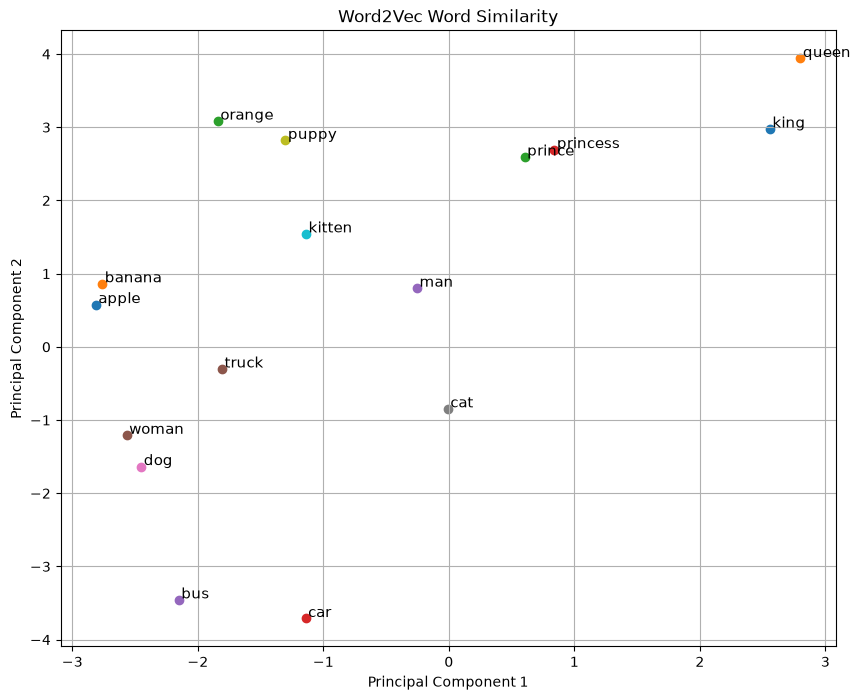

In [118]:
# Word2Vec Embedding PCA 시각화
embedding_cpu = (
    model.embedding.weight
    .detach()
    .cpu()
    .numpy()
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

vectors_2d = pca.fit_transform(
    embedding_cpu
)

words = [
    "king", "queen",
    "prince", "princess",
    "man", "woman",
    "dog", "cat",
    "puppy", "kitten",
    "apple", "banana", "orange",
    "car", "bus", "truck"
]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for word in words:
    i = word_to_id[word]
    x = vectors_2d[i, 0]
    y = vectors_2d[i, 1]

    plt.scatter(x, y)

    plt.text(
        x + 0.02,
        y + 0.02,
        word,
        fontsize=11
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Word2Vec Word Similarity")
plt.grid(True)
plt.show()